**MAESTRÍA EN INTELIGENCIA ARTIFICIAL APLICADA**

**Curso: TC5053 - Ciencia y analítica de datos**

Tecnológico de Monterrey

Prof Grettel Barceló Alonso

**Semana 5**
Preprocesamiento de datos

---

*   NOMBRE: Darío Martín Romero Cruz
*   MATRÍCULA: A01841015

En esta actividad trabajarás con el archivo `heart_disease.csv`, basado en un conjunto de datos sobre pacientes y variables clínicas relacionadas con enfermedades cardíacas, disponible en Kaggle.

Los datos fueron recopilados para analizar la presencia de enfermedades cardíacas en los pacientes y contienen información demográfica, clínica y resultados de pruebas diagnósticas. Los indicadores incluidos son:

* `id`: Identificador único de cada paciente
* `age`: Edad del paciente en años
* `origin`: Lugar de estudio
* `sex`: Masculino / Femenino
* `cp`: Tipo de dolor torácico (angina típica, angina atípica, no anginal, asintomático)
* `trestbps`: Presión arterial en reposo (en mm Hg al ingreso al hospital)
* `chol`: Colesterol sérico en mg/dl
* `fbs`: Si el azúcar en ayunas > 120 mg/dl
* `restecg`: Resultados del electrocardiograma en reposo (normal, anomalía ST-T, hipertrofia ventricular izquierda)
* `thalach`: Frecuencia cardíaca máxima alcanzada
* `exang`: Angina inducida por ejercicio (Verdadero / Falso)
* `oldpeak`: Depresión del segmento ST inducida por ejercicio respecto al reposo
* `slope`: Pendiente del segmento ST en el pico de ejercicio
* `ca`: Número de vasos principales coloreados por fluoroscopía (0 - 3)
* `thal`: Resultado de la prueba de perfusión cardíaca (normal, defecto fijo, defecto reversible)
* `num`: Indica si el paciente tiene o no enfermedad cardíaca, o el grado de enfermedad (0 = sano, 1 - 4 = enfermedad) Es la variable de salida o *target*, es decir, la que se pretende predecir más adelante al construir el modelo.

**NOTA IMPORTANTE:** Asegúrate de responder *explícitamente* todos los cuestionamientos.

In [1]:
# Importar las bibliotecas necesarias
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.impute import SimpleImputer

1. Descarga el archivo: `heart_disease.csv` y guarda, en un dataframe (`cardio_df`), todos sus registros.
* Haz que la columna `id` sea el índice del dataframe.
* Utiliza el método `info()` del dataframe, para obtener el resumen de los tipos de datos. ¿Cuántas columnas son numéricas y cuántas de texto?
* Determina la cantidad de valores únicos por columna.

In [2]:
cardio_df = pd.read_csv('heart_disease.csv', sep = ',', index_col = 'id') #Leer informacion

#Identificar columnas numericas y no numericas
ColNum = list(cardio_df.dtypes.loc[cardio_df.dtypes.astype(str).isin(['int64', 'float64', 'int', 'float'])].index) #Lista de columnas numericas
ColNoNum = list(cardio_df.dtypes.loc[cardio_df.dtypes.astype(str).isin(['string', 'object', 'category'])].index) #Lista de columnas string

cardio_unique = cardio_df.nunique() #Identificar valores unicos

#Imprimir resultados
print('Tipos de datos de nuestro archivo:\n')
cardio_df.info()

print(f'\nTotal de filas: {cardio_df.shape[0]}')
print(f'Total de columnas: {cardio_df.shape[1]}')

print(f'  > Numericas: {len(ColNum)}')
print(f'  > No numericas: {len(ColNoNum)}')

#Mostrar valores unicos por columnas, se decide separar para hacer mas facil el siguiente punto
print('\nCantidad de valores unicos por columnas numericas:')
for Col in ColNum:
    print(f'  > {Col}: {cardio_unique[Col]:,}')

print('\nCantidad de valores unicos por columnas no numericas:')
for Col in ColNoNum:
    print(f'  > {Col}: {cardio_unique[Col]:,}')

Tipos de datos de nuestro archivo:

<class 'pandas.core.frame.DataFrame'>
Index: 918 entries, 1 to 920
Data columns (total 15 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       918 non-null    int64  
 1   sex       918 non-null    object 
 2   origin    918 non-null    object 
 3   cp        918 non-null    object 
 4   trestbps  859 non-null    float64
 5   chol      888 non-null    float64
 6   fbs       829 non-null    object 
 7   restecg   918 non-null    object 
 8   thalch    863 non-null    float64
 9   exang     863 non-null    object 
 10  oldpeak   856 non-null    float64
 11  slope     610 non-null    object 
 12  ca        309 non-null    float64
 13  thal      434 non-null    object 
 14  num       918 non-null    int64  
dtypes: float64(5), int64(2), object(8)
memory usage: 114.8+ KB

Total de filas: 918
Total de columnas: 15
  > Numericas: 7
  > No numericas: 8

Cantidad de valores unicos por columnas numericas:
  > a

2. Examina las variables numéricas que presentan pocos valores únicos, ya que esto puede indicar que en realidad se tratan de variables categóricas codificadas como números.
* Si existen casos de este tipo, conviértelas a categóricas. Antes de hacerlo, revisa sus descripciones para determinar si son ordinales o nominales y, si son ordinales, establece el orden correcto de las categorías.

In [3]:
#Analizar elementos de las columnas numericas con pocos valores unicos (<10)
print('Columnas con pocos valores unicos:')
for Col in ColNum:
    if cardio_unique[Col] < 10:
        print(f'\n  > {Col}')
        for i, Row in cardio_df[Col].value_counts(dropna = False).reset_index().sort_values(Col).iterrows():
            print(f'     {Row[Col]}: {Row['count']}')

#Definir a num como variable categorica
cardio_df['num'] = cardio_df.num.astype('category')
cardio_df['num'] = cardio_df.num.cat.set_categories([0, 1, 2, 3, 4], ordered = True)
print('\nColumna "num" pasa a tipo category.')

#Identificar columnas numericas y no numericas
ColNum = list(cardio_df.dtypes.loc[cardio_df.dtypes.astype(str).isin(['int64', 'float64', 'int', 'float'])].index) #Lista de columnas numericas
ColNoNum = list(cardio_df.dtypes.loc[cardio_df.dtypes.astype(str).isin(['string', 'object', 'category'])].index) #Lista de columnas string

print(f'\nTotal de columnas: {cardio_df.shape[1]}')

print(f'  > Numericas: {len(ColNum)}')
print(f'  > No numericas: {len(ColNoNum)}')


Columnas con pocos valores unicos:

  > ca
     0.0: 181.0
     1.0: 67.0
     2.0: 41.0
     3.0: 20.0
     nan: 609.0

  > num
     0: 411
     1: 263
     2: 109
     3: 107
     4: 28

Columna "num" pasa a tipo category.

Total de columnas: 15
  > Numericas: 6
  > No numericas: 9


**Análisis**:  
Aunque 2 columnas cumplen lo de tener valores numéricos y pocos valores únicos, revisando los datos que tienen y su descripción, concluyo que solo **num** es categórica, la cual puede tomar valores en {0, 1, 2, 3, 4} de acuerdo a si es saludable o el tipo de enfermedad. **ca** por otro lado es una variable numérica discreta, que puede tomar valores en {1, 2, 3}.

3. Obtén las estadísticas descriptivas de las variables, realizando el análisis por separado para las variables numéricas y las categóricas.
* Para las numéricas, incluye el sesgo y la curtosis.
* Para las categóricas, imprime además las tablas de frecuencia.

In [4]:
#Obtener estadísticas de las columnas numericas
Stat = cardio_df[ColNum].describe(percentiles = [0.05, 0.95])
Stat = pd.concat([Stat, cardio_df[ColNum].agg(['skew', 'kurt'])]) #Agregar sesgo y curtosis

#Imprimir resultados
print('Estadistica descriptiva de las variables numericas\n')
print(Stat.round(2))


#Obtener estadísticas de las columnas categoricas
cardio_df[ColNoNum] = cardio_df[ColNoNum].astype('category') #Pasa columnas tipo object a categoricas
Stat = cardio_df[ColNoNum].describe()

#Imprimir resultados
print('\n\nEstadistica descriptiva de las variables categoricas:\n')
print(Stat.round(2))

print('\n\nTabla de frecuencia por columna categorica:')
for Col in ColNoNum:
    print(f'\n  > {Col}')
    for i, Row in cardio_df[Col].value_counts(dropna = False).reset_index().iterrows():
        print(f'     {Row[Col]}: {Row['count']}')

Estadistica descriptiva de las variables numericas

          age  trestbps    chol  thalch  oldpeak      ca
count  918.00    859.00  888.00  863.00   856.00  309.00
mean    53.53    132.29  242.19  137.53     0.88    0.68
std      9.41     18.54   53.42   25.95     1.09    0.94
min     28.00     80.00   85.00   60.00    -2.60    0.00
5%      37.00    105.90  172.35   95.00     0.00    0.00
50%     54.00    130.00  223.00  140.00     0.50    0.00
95%     68.00    160.40  334.30  178.00     3.00    3.00
max     77.00    200.00  603.00  202.00     6.20    3.00
skew    -0.19      0.63    1.64   -0.21     1.04    1.17
kurt    -0.38      0.63    6.57   -0.48     1.12    0.20


Estadistica descriptiva de las variables categoricas:

         sex     origin            cp    fbs restecg  exang slope    thal  num
count    918        918           918    829     918    863   610     434  918
unique     2          4             4      2       3      2     3       3    5
top     Male  Cleveland  as

4. Calcula el porcentaje de valores faltantes en cada columna.
* Elimina aquellas columnas cuyo porcentaje de valores faltantes supere el 30%.
* Crea un mapa de calor que visualice la distribución de los valores faltantes en todas las columnas restantes.
* Algunas variables presentan valores faltantes de manera simultánea; es decir, en el mapa se pueden identificar filas donde varias están ausentes al mismo tiempo. Enumera cuáles son dichas variables e investiga si esta concurrencia tiene sentido desde un punto de vista médico o clínico.

Valores faltantes por columna
  > age: 0 (0.0%)
  > sex: 0 (0.0%)
  > origin: 0 (0.0%)
  > cp: 0 (0.0%)
  > trestbps: 59 (6.4%)
  > chol: 30 (3.3%)
  > fbs: 89 (9.7%)
  > restecg: 0 (0.0%)
  > thalch: 55 (6.0%)
  > exang: 55 (6.0%)
  > oldpeak: 62 (6.8%)
  > slope: 308 (33.6%) <- Eliminar columna
  > ca: 609 (66.3%) <- Eliminar columna
  > thal: 484 (52.7%) <- Eliminar columna
  > num: 0 (0.0%)

Mapa de calor de valores faltantes (rojo):


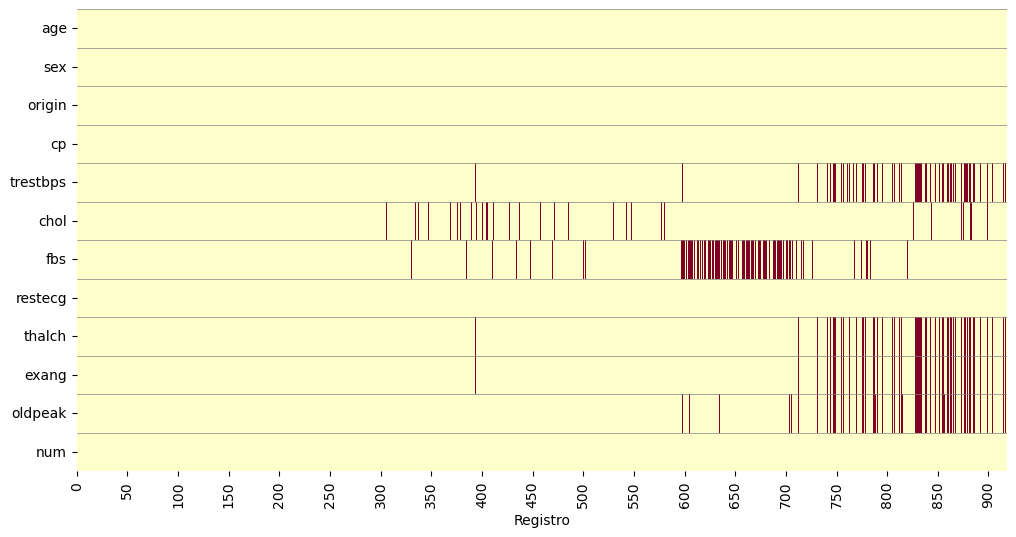

In [5]:
import seaborn as sns
import matplotlib.pyplot as plt

#Revisar porcentaje de valores faltantes por columnas. Si porcentaje > 30% eliminar
ColDel = [] #Columnas a eliminar
print('Valores faltantes por columna')
for Col in cardio_df.columns:
    n = sum(cardio_df[Col].isna())
    p = n / cardio_df.shape[0]
    
    if p > 0.3:
        print(f'  > {Col}: {n:,} ({p:.1%}) <- Eliminar columna')
        ColDel += [Col]
    else:
        print(f'  > {Col}: {n:,} ({p:.1%})')

cardio_df = cardio_df.drop(columns = ColDel)
ColNum = [Col for Col in ColNum if Col not in ColDel]
ColNoNum = [Col for Col in ColNoNum if Col not in ColDel]

#Mapa de calor de la distribución de los datos faltantes
print('\nMapa de calor de valores faltantes (rojo):')
Fig, Ax = plt.subplots(figsize = (12,6))

sns.heatmap(cardio_df.isna().T, cbar = False, cmap = 'YlOrRd', ax = Ax)
for y in range(cardio_df.shape[1]):
    Ax.axhline(y, color = 'gray', lw = 0.5)

#Definir xticks
xTicks = np.arange(0, cardio_df.shape[0] + 1, 50)
Ax.set_xticks(xTicks)
Ax.set_xticklabels(xTicks)
Ax.set_xlabel('Registro')

plt.show()

**Análisis**:  
Viendo el mapa de calor, se observa que la distribución de los missing values se repite para las columnas: **trestbps** (presión arterial en reposo), **thalch** (frecuencia cardiaca maxima), **exang** (angina inducida por ejercicio) y **oldpeak** (depresión del segmento inducida por ejercicio). Es posible que estos sean resultados de un mismo estudio realizados después de un ingreso hospitalario, pero no a todos los individuos se les ha hecho la prueba.

5. Si centramos el análisis en una de las variables identificadas en el ejercicio anterior, se puede suponer que los hallazgos obtenidos podrían ser aplicables a las demás variables que presentan un patrón similar.

* ¿Tendrán los valores faltantes de `thalch` relación con alguna otra variable? Analízalo considerando las siguientes columnas:
  *   Numéricas: `age`, `chol`
  *   Categóricas: `restecg`, `cp`

Para ello deberás dividir cada columna en dos grupos: con / sin faltantes en `thalch` y utilizar métodos gráficos y pruebas de hipótesis para ver si hay diferencias significativas.
* Incluye las conclusiones del análisis con los resultados obtenidos.
* Justifica si el mecanismo de faltantes de `thalch` es MCAR (*Missing Completely at Random*) o MAR (*Missing at Random*).

**NOTA**. Puedes reutilizar las funciones `Diagnose_MV_Numerical` y `Diagnose_MV_Categorical` definidas en Hands-On-Prep_Missing_Values.zip. Revisa nuevamente cómo utilizarlas.

In [6]:
from scipy.stats import ttest_ind
def Diagnose_MV_Numerical(df,str_att_name,BM_MV):
    MV_labels = {True:'With Missing Values',False:'Without Missing Values'}

    labels=[]
    box_sr = pd.Series('',index = BM_MV.unique())
    for poss in BM_MV.unique():
        BM = BM_MV == poss
        box_sr[poss] = df[BM][str_att_name].dropna()
        labels.append(MV_labels[poss])

    plt.boxplot(box_sr,vert=False)
    plt.yticks([1,2],labels)
    plt.xlabel(str_att_name)
    plt.show()

    plt.figure(figsize=(10,4))

    att_range = (df[str_att_name].min(),df[str_att_name].max())

    for i,poss in enumerate(BM_MV.unique()):
        plt.subplot(1,2,i+1)
        BM = BM_MV == poss
        df[BM][str_att_name].hist()
        plt.xlim(att_range) #Linea modificada, corrige un error en el codigo del libro
        plt.xlabel(str_att_name)
        plt.title(MV_labels[poss])
        plt.axvline(df[BM_MV == False][str_att_name].mean(), color = 'red')  #Linea agregada, media de los datos sin missing values usada como referencia

    plt.show()

    group_1_data = df[BM_MV][str_att_name].dropna()
    group_2_data = df[~BM_MV][str_att_name].dropna()

    p_value = ttest_ind(group_1_data,group_2_data).pvalue

    print('p-value of t-test: {:.6f}'.format(p_value))

In [7]:
from scipy.stats import chi2_contingency
def Diagnose_MV_Categorical(df,str_att_name,BM_MV):
    MV_labels = {True:'With Missing Values',False:'Without Missing Values'}

    plt.figure(figsize=(10,4))
    for i,poss in enumerate(BM_MV.unique()):
        plt.subplot(1,2,i+1)
        BM = BM_MV == poss
        df[BM][str_att_name].value_counts().sort_index().plot.bar() #Linea modificada, ordenar por index
        plt.title(MV_labels[poss])
    plt.show()

    contigency_table = pd.crosstab(BM_MV,df[str_att_name])
    p_value = chi2_contingency(contigency_table)[1]

    print('p-value of Chi_squared test: {:.6f}'.format(p_value))

age:


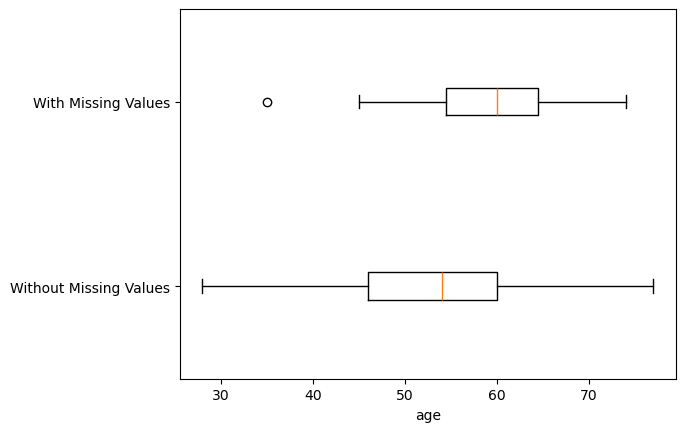

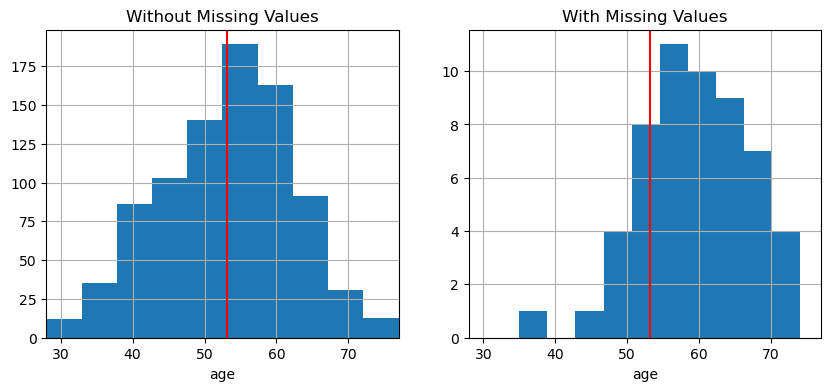

p-value of t-test: 0.000002


chol


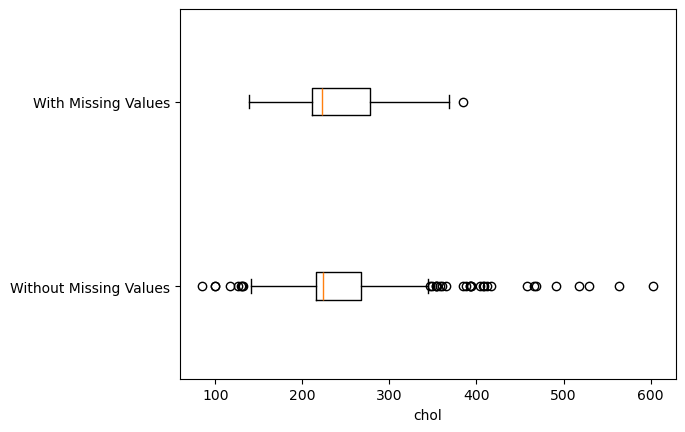

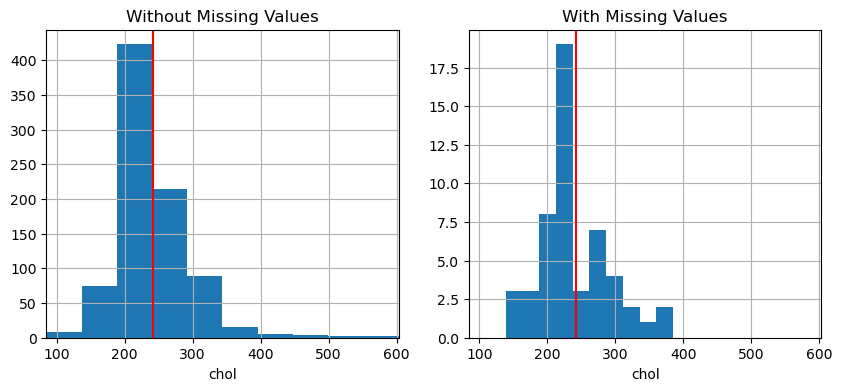

p-value of t-test: 0.716529


restecg


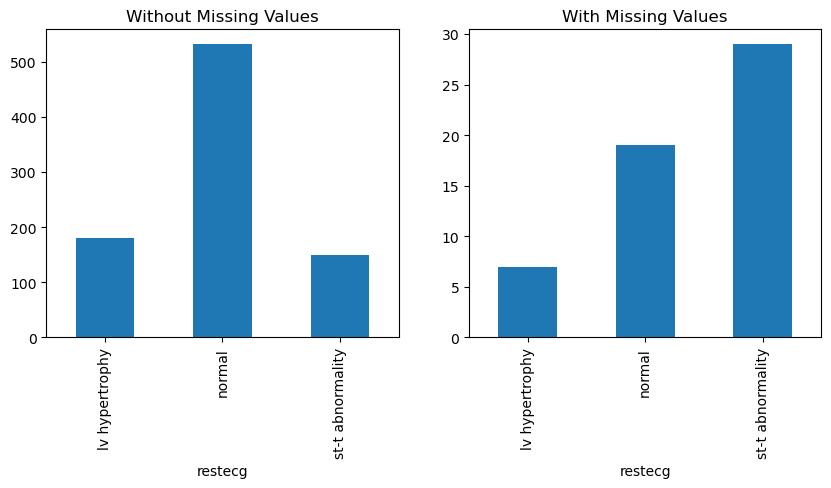

p-value of Chi_squared test: 0.000000


cp


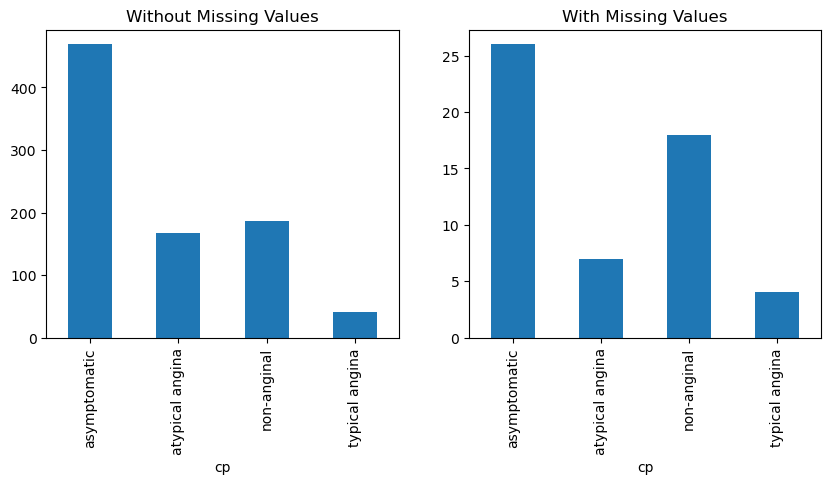

p-value of Chi_squared test: 0.154201


In [8]:
BM_MV = cardio_df.thalch.isna()

#Analizar columnas numericas
print('age:')
Diagnose_MV_Numerical(cardio_df, 'age', BM_MV)
print('\n\nchol')
Diagnose_MV_Numerical(cardio_df, 'chol',BM_MV)

#Analizar columnas categoricas
print('\n\nrestecg')
Diagnose_MV_Categorical(cardio_df, 'restecg',BM_MV)
print('\n\ncp')
Diagnose_MV_Categorical(cardio_df, 'cp',BM_MV)

**Resultados:**  
- En el caso de las **variables númericas**, la prueba aplicada se basa en un t de Student para evaluar si la diferencia en las medias de los dos grupos (los datos que tienen missing values en **thalch** y los que no) es estadísticamente significativa. Tomando como nivel de significancia el estándar de 0.05, obtenemos que para el caso de **age** se rechaza nuestra hipótesis nula de que las medias son iguales (p-value cercano a 0), por lo que nos quedaríamos con la hipótesis alternativa de que son diferentes. Esto sugiere que la distribución de los grupos es estadísticamente diferente y por lo tanto los missing values en **thalch** están relacionados con **age** (MAR).  
- Para **chol** la prueba nos da un p-value alto (0.71), con lo que no se puede rechazar que las medias sean iguales. Esto nos diría que al menos con **chol**, la presencia de missing values en **thalch** no parece estar relacionada.  
- Para las **variables categóricas**, estamos aplicando una prueba chi cuadrada cuya hipotesis nula es que hay independencia en las variables en la tabla de contingencia formada por nuestra variable categórica y **thalch**. Para el caso de **restecg**, con un p-value casi 0 entonces se rechaza independencia por lo que podríamos decir que la presencia de missing values está relacionada a este parámetro.  
- Finalmente, en el caso de **cp** con un p-value de 0.15, no podemos rechazar independencia. Por lo que a priori no esta relacionada con los missing values.
  
De todo lo anterior, concluimos que los valores faltantes en **thalch** no cumplen con el escenario **MCAR** ya que su existencia si parece estar relacionada a los parámetros de **age** y **restecg**, por lo que sería **MAR**.

6. La imputación de una variable con valores faltantes puede realizarse por grupos o segmentos relevantes. Esto significa que, en lugar de utilizar una estadística global de toda la columna, se calcula la estadística correspondiente dentro de cada grupo definido por otra variable, haciendo:

> `df['var_with_missing'] = df.groupby('related_var')['var_with_missing'].transform(lambda x: x.fillna(x.median()))`

* Utiliza la variable `restecg` para separar los grupos e imputar `thalch` y todas las variables con patrón de faltantes similar (identificadas en el ejercicio 4) Asegúrate de cambiar la función de agregado si hay variables no numéricas.
* Vuelve a generar el mapa de calor para verificar que los valores faltantes en estas variables hayan sido imputados.


Mapa de calor de valores faltantes (rojo) actualizado:


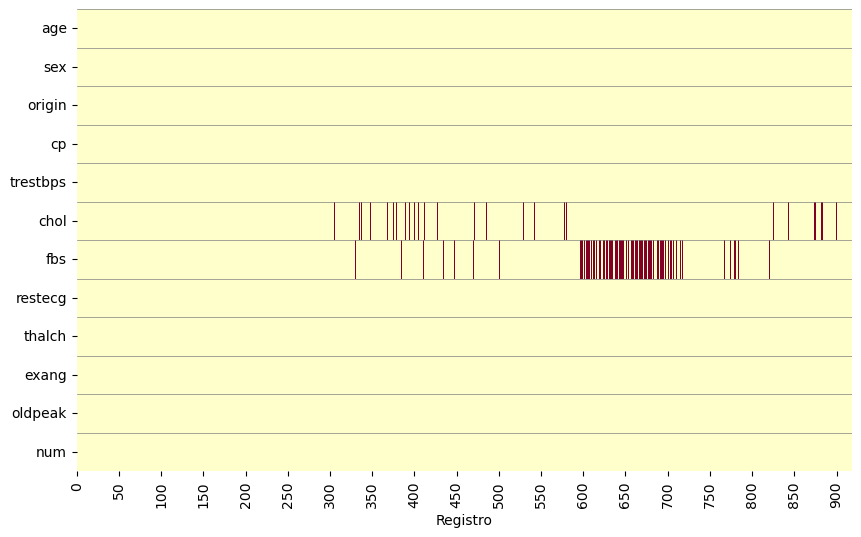

In [9]:
for Col in ['thalch', 'trestbps', 'exang', 'oldpeak']:
    if Col in ColNum:
        cardio_df[Col] = cardio_df.groupby('restecg', observed = True)[Col].transform(lambda x: x.fillna(x.median()))
    else:
        cardio_df[Col] = cardio_df.groupby('restecg', observed = True)[Col].transform(lambda x: x.fillna(x.mode()[0]))



#Mapa de calor de la distribución de los datos faltantes
print('\nMapa de calor de valores faltantes (rojo) actualizado:')
Fig, Ax = plt.subplots(figsize = (10, 6))

sns.heatmap(cardio_df.isna().T, cbar = False, cmap = 'YlOrRd', ax = Ax)
for y in range(cardio_df.shape[1]):
    Ax.axhline(y, color = 'gray', lw = 0.5)

#Definir xticks
xTicks = np.arange(0, cardio_df.shape[0] + 1, 50)
Ax.set_xticks(xTicks)
Ax.set_xticklabels(xTicks)
Ax.set_xlabel('Registro')

plt.show()

**Resultados**: Se observa como las 4 variables relacionadas ya no presentan valores faltantes (**thalch**, **trestbps**, **exang**, **oldpeak**). Quedando estos solo en **chol** y **fbs**.

7. Para las variables que aún presentan valores faltantes, realiza la imputación utilizando estadísticas generales calculadas sobre toda la columna, sin segmentar por grupos. Esta vez utiliza la clase `SimpleImputer` de sklearn
* Justifica la estrategia (*mean, median, most_frequent*) que emplees en cada caso.


Revision de las variables con valores faltantes para determinar estrategía de llenado.

Analisis de chol: 
  > Media: 242.19
  > Mediana: 223.00
  > Moda: 223.00


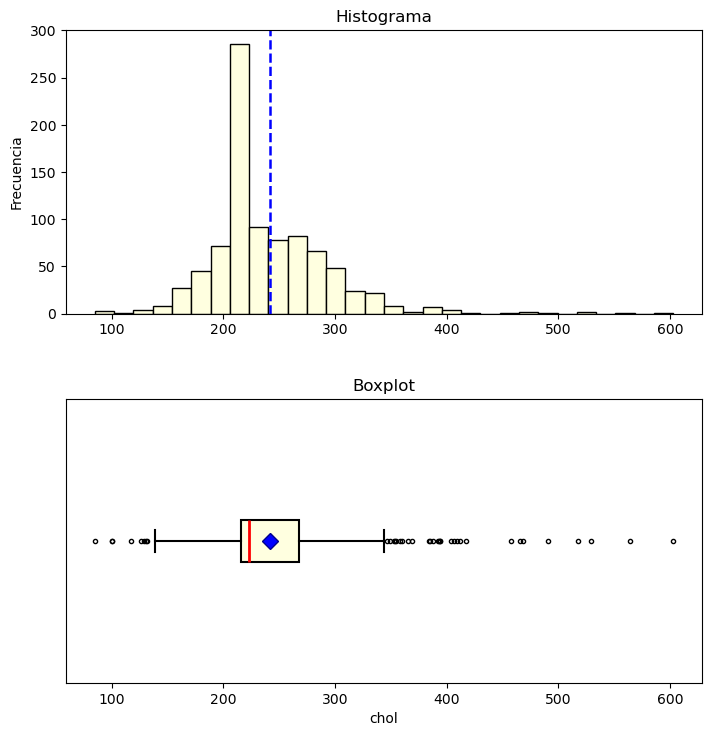


Analisis de fbs. Tabla de frecuencias:
  > False: 691
  > True: 138
  > nan: 89


In [10]:
from sklearn.impute import SimpleImputer

print('Revision de las variables con valores faltantes para determinar estrategía de llenado.')

#Analisis chol
print(f'\nAnalisis de chol: \n  > Media: {cardio_df['chol'].mean():.2f}')
print(f'  > Mediana: {cardio_df['chol'].median():.2f}')
print(f'  > Moda: {cardio_df['chol'].mode()[0]:.2f}')

#Grafico
Fig = plt.figure(figsize = (8, 8))

#Histograma
Ax1 = Fig.add_subplot(2, 1, 1)
Ax1.hist(cardio_df['chol'].dropna(), bins = 30, density = False, color = 'lightyellow', edgecolor = 'black')
Ax1.axvline(cardio_df['chol'].mean(), color = 'blue', ls = '--', lw = 1.8)

Ax1.set_ylabel('Frecuencia')
Ax1.set_title('Histograma')

#Boxplot
Ax2 = Fig.add_subplot(2, 1, 2)
Ax2.boxplot(cardio_df['chol'].dropna(), vert = False, patch_artist = True, boxprops = dict(facecolor = 'lightyellow', lw = 1.5), medianprops = dict(color = 'red', lw = 2), whiskerprops = dict(color = 'black', lw = 1.5), 
               capprops = dict(color = 'black', lw = 1.5), flierprops = dict(marker = 'o', ms = 3),
               showmeans = True, meanprops = dict(marker = 'D', ms = 8, mfc = 'blue', mec = 'darkblue'))
Ax2.set_title('Boxplot')
Ax2.set_xlabel('chol')
Ax2.set_yticks([])

Fig.tight_layout(pad = 1.0, w_pad = 3, h_pad = 3, rect=[0.05, 0.05, 0.95, 0.98])
plt.show()


#Analisis fbs
print('\nAnalisis de fbs. Tabla de frecuencias:')
for i, Row in cardio_df.fbs.value_counts(dropna = False).reset_index().iterrows():
    print(f'  > {Row.fbs}: {Row['count']}')


#Completar missing values
imputer = SimpleImputer(strategy = 'median')
cardio_df['chol'] = imputer.fit_transform(cardio_df[['chol']])

imputer = SimpleImputer(strategy = 'most_frequent')
cardio_df['fbs'] = imputer.fit_transform(cardio_df[['fbs']])


**Justificacion:**  
Para este problema grafiqué los valores de **chol** para saber su distribución. Al observar histograma y boxplot se puede observar una alta presencia de outliers a la derecha que podrían afectar a la media. Además, observamos como la mediana y moda coinciden. Por lo que he decidido usar la mediana como estimador para los datos que faltan.  
En el caso de **fbs** se usa la moda ya que es una variable tipo categorica (True o False).

8. Dibuja boxplots de todas las variables numéricas.
* Obtén los valores atípicos mediante el método gráfico, a partir del objeto devuelto por el boxplot.

Outliers encontrados con el metodo grafico: 
  > age: 
  > trestbps: 80, 172, 172, 174, 178, 178, 178, 180, 180, 180, 180, 180, 180, 180, 180, 180, 180, 180, 180, 185, 190, 190, 192, 200, 200, 200, 200
  > chol: 85, 100, 100, 117, 126, 129, 131, 132, 139, 141, 142, 342, 342, 342, 344, 347, 349, 353, 354, 355, 358, 360, 365, 369, 384, 385, 388, 392, 393, 394, 394, 404, 407, 409, 412, 417, 458, 466, 468, 491, 518, 529, 564, 603
  > thalch: 60, 63
  > oldpeak: -2, 3, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 5, 5, 6


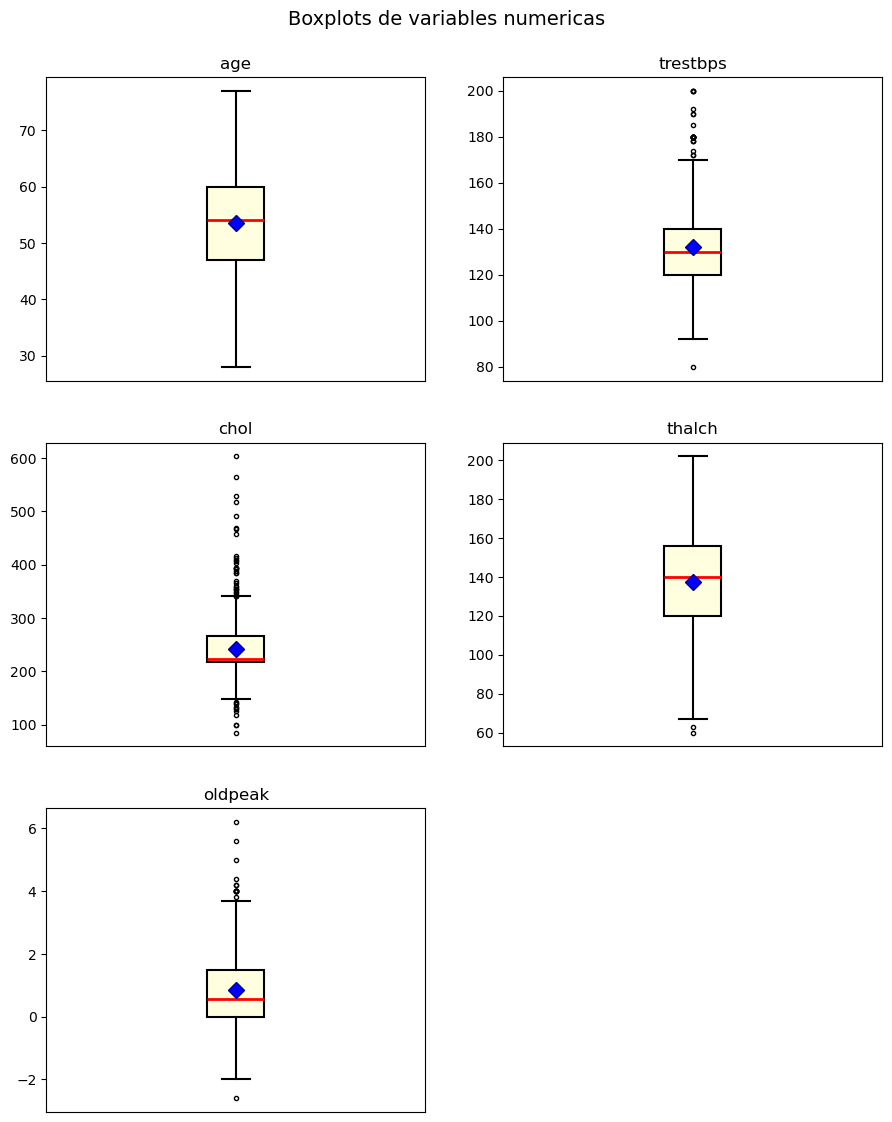

In [11]:
print('Outliers encontrados con el metodo grafico: ')

#Boxplot
Fig = plt.figure(figsize = (10, 12))
i = 0

for Col in ColNum:
    i += 1
    Ax = Fig.add_subplot(3, 2, i)

    #Boxplot
    x = cardio_df[Col]
    bp = Ax.boxplot(x, vert = True, patch_artist = True, boxprops = dict(facecolor = 'lightyellow', lw = 1.5), medianprops = dict(color = 'red', lw = 2), whiskerprops = dict(color = 'black', lw = 1.5), 
                    capprops = dict(color = 'black', lw = 1.5), flierprops = dict(marker = 'o', ms = 3),
                    showmeans = True, meanprops = dict(marker = 'D', ms = 8, mfc = 'blue', mec = 'darkblue'))

    Ax.set_title(Col)
    Ax.set_xticks([])

    # Extrae outliers de esta iteración
    outliers = list(bp['fliers'][0].get_data()[1])
    outliers.sort()
    
    #Lista con los ouliers de trestbps para comprobar con problema 9
    if Col == 'trestbps':
        outliers_trestbps_a = outliers

    outliers = [str(int(v)) for v in outliers]
    print(f'  > {Col}: {', '.join(outliers)}')

Fig.suptitle('Boxplots de variables numericas', fontsize = 14)    
Fig.tight_layout(pad = 1.0, w_pad = 3, h_pad = 3, rect=[0.05, 0.05, 0.95, 0.98])

9. Para la variable `trestbps`, calcula los valores atípicos utilizando el método del rango intercuartílico (IQR).
* Para ello obtén los cuartiles necesarios y determina los límites superior e inferior para filtrar los valores que se encuentren fuera de ese rango.
* Verifica si los resultados coinciden con los obtenidos en el ejercicio anterior.

In [12]:
#copio los datos solo de trestbps en un nuevo dataframe, para eliminarlos despues en el problema 10 sin afectar todos los datos
cardio_trestbps = cardio_df['trestbps'].copy()

Q1 = cardio_trestbps.quantile(0.25)
Q2 = cardio_trestbps.quantile(0.50) #Mediana
Q3 = cardio_trestbps.quantile(0.75)

IQR = Q3 - Q1

LimL = Q1 - 1.5*IQR
LimU = Q3 + 1.5*IQR

I = (cardio_trestbps < LimL) | (cardio_trestbps > LimU)
outliers_trestbps_b = list(cardio_trestbps.loc[I].sort_values())
outliers = [str(int(v)) for v in outliers_trestbps_b]
print(f'Outliers de "trestbps" por metodo IQR: {', '.join(outliers)}')

if outliers_trestbps_a == outliers_trestbps_b:
    print('\n  > La lista coincide con la del ejercicio anterio.')
else:
    print('\n  > La lista no coincide con la del ejercicio anterio.')


Outliers de "trestbps" por metodo IQR: 80, 172, 172, 174, 178, 178, 178, 180, 180, 180, 180, 180, 180, 180, 180, 180, 180, 180, 180, 185, 190, 190, 192, 200, 200, 200, 200

  > La lista coincide con la del ejercicio anterio.


10. Elimina los valores atípicos identificados de la variable `trestbps`.
* Dibuja el boxplot final para visualizar la distribución depurada.

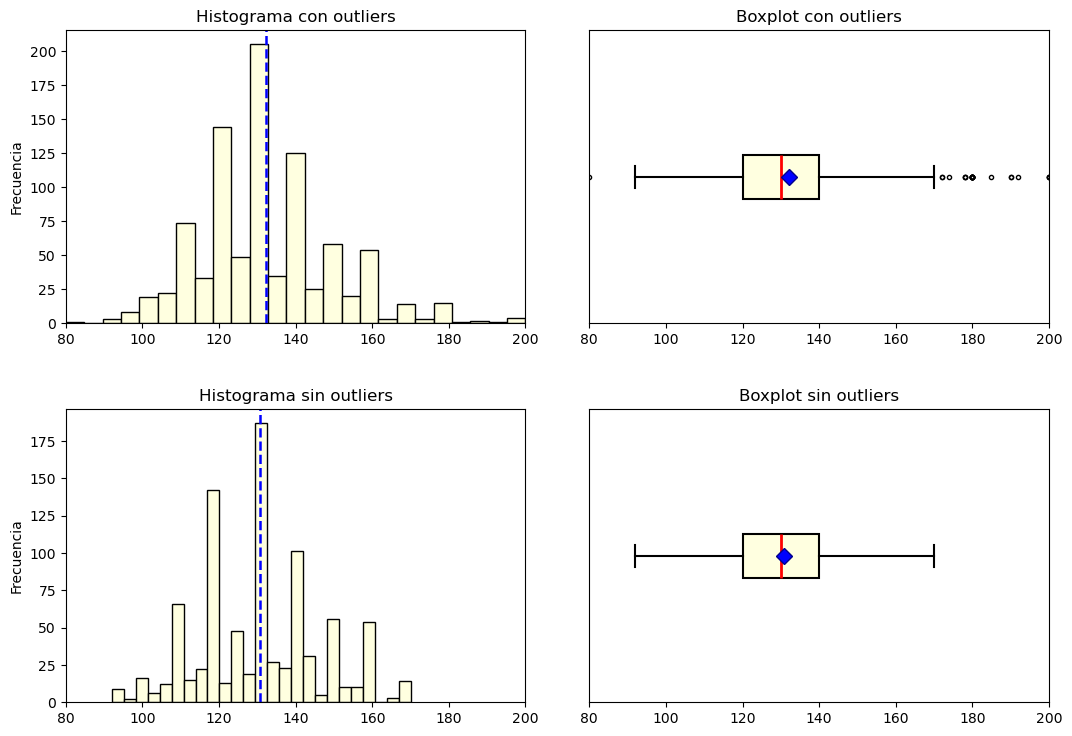

In [13]:
x_range = (cardio_trestbps.min(), cardio_trestbps.max())

Fig = plt.figure(figsize = (12, 8))

for i in range(2):

    #Histograma
    Ax1 = Fig.add_subplot(2, 2, i*2 + 1)
    Ax1.hist(cardio_trestbps, bins = 25, density = False, color = 'lightyellow', edgecolor = 'black')
    Ax1.axvline(cardio_trestbps.mean(), color = 'blue', ls = '--', lw = 1.8)

    Ax1.set_ylabel('Frecuencia')
    Ax1.set_title(f'Histograma {'con' if i == 0 else 'sin'} outliers')
    Ax1.set_xlim(x_range)

    #Boxplot
    Ax2 = Fig.add_subplot(2, 2, i*2 + 2)
    Ax2.boxplot(cardio_trestbps, vert = False, patch_artist = True, boxprops = dict(facecolor = 'lightyellow', lw = 1.5), medianprops = dict(color = 'red', lw = 2), whiskerprops = dict(color = 'black', lw = 1.5), 
                capprops = dict(color = 'black', lw = 1.5), flierprops = dict(marker = 'o', ms = 3),
                showmeans = True, meanprops = dict(marker = 'D', ms = 8, mfc = 'blue', mec = 'darkblue'))
    Ax2.set_title(f'Boxplot {'con' if i == 0 else 'sin'} outliers')
    Ax2.set_yticks([])
    Ax2.set_xlim(x_range)

    if i == 0:
        cardio_trestbps = cardio_trestbps.loc[~I].copy()

Fig.tight_layout(pad = 1.0, w_pad = 3, h_pad = 3, rect=[0.05, 0.05, 0.95, 0.98])




---

**Declaración de uso de IA**

*   OpenAI. (2026). *ChatGPT (basado en GPT-5.5)* [Modelo de lenguaje grande], utilizado para generación de código, explicación de conceptos y exploración de ideas. https://chat.openai.com/
*   Anthropic. (2026). *Claude Sonnet 4.6* [Modelo de lenguaje grande], utilizado para generación de código, explicación de conceptos y exploración de ideas. https://claude.ai/


---